## Load and merge air data

In [6]:
from matplotlib import figure
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("talk")

def load_and_merge_air_csvs(folder_path="data/air data", pattern="*.csv"):
    folder = Path(folder_path)
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder.resolve()}")

    dataframes = [pd.read_csv(file) for file in csv_files]
    merged_df = pd.concat(dataframes, ignore_index=True)
    return merged_df

folder = Path("../data/air data/")
figure_folder = Path("../figures/air data")
merged_df = load_and_merge_air_csvs(folder_path=folder)


variables = ['Good Days', 'Unhealthy for Sensitive Groups Days', 'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days']
for var in variables:
    merged_df[f'{var} % of Total'] = (merged_df[var] / merged_df['Days with AQI']) * 100


print(f'Data Contains the following states: {np.unique(merged_df["State"])}')

# remove mexico!
merged_df = merged_df[merged_df['State'] != 'Country Of Mexico']
merged_df.head()



Data Contains the following states: ['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Country Of Mexico' 'Delaware' 'District Of Columbia'
 'Florida' 'Georgia' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas'
 'Kentucky' 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan'
 'Minnesota' 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada'
 'New Hampshire' 'New Jersey' 'New Mexico' 'New York' 'North Carolina'
 'North Dakota' 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Puerto Rico'
 'Rhode Island' 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'Utah'
 'Vermont' 'Virgin Islands' 'Virginia' 'Washington' 'West Virginia'
 'Wisconsin' 'Wyoming']


,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,...,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,Good Days % of Total,Unhealthy for Sensitive Groups Days % of Total,Unhealthy Days % of Total,Very Unhealthy Days % of Total,Hazardous Days % of Total
0,Alabama,Baldwin,2016,279,233,46,0,0,0,0,...,0,0,189,90,0,83.512545,0.000000,0.0,0.0,0.0
1,Alabama,Clay,2016,116,83,33,0,0,0,0,...,0,0,0,116,0,71.551724,0.000000,0.0,0.0,0.0
2,Alabama,Colbert,2016,282,241,40,1,0,0,0,...,0,0,193,89,0,85.460993,0.354610,0.0,0.0,0.0
3,Alabama,DeKalb,2016,348,282,65,1,0,0,0,...,0,0,293,55,0,81.034483,0.287356,0.0,0.0,0.0
4,Alabama,Elmore,2016,117,107,10,0,0,0,0,...,0,0,117,0,0,91.452991,0.000000,0.0,0.0,0.0


## Visualize the distribution over the years

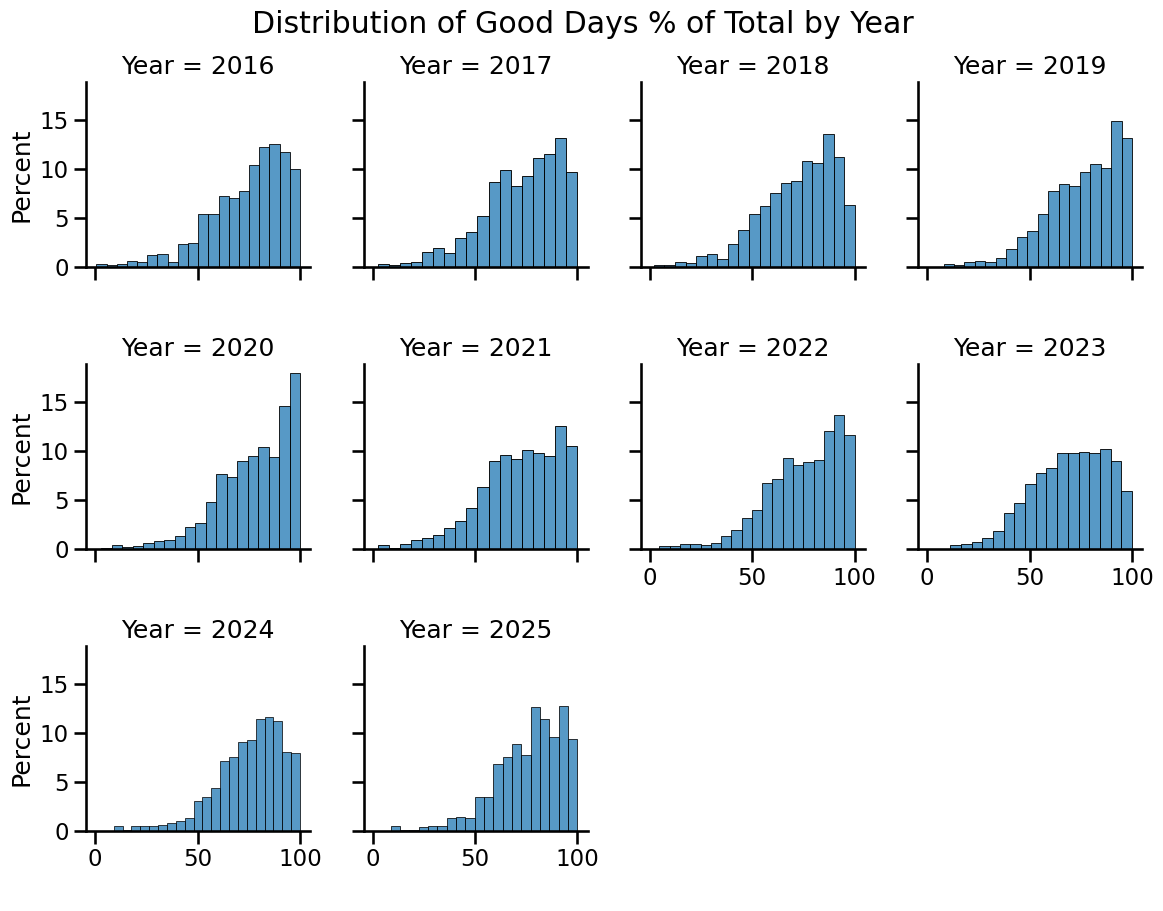

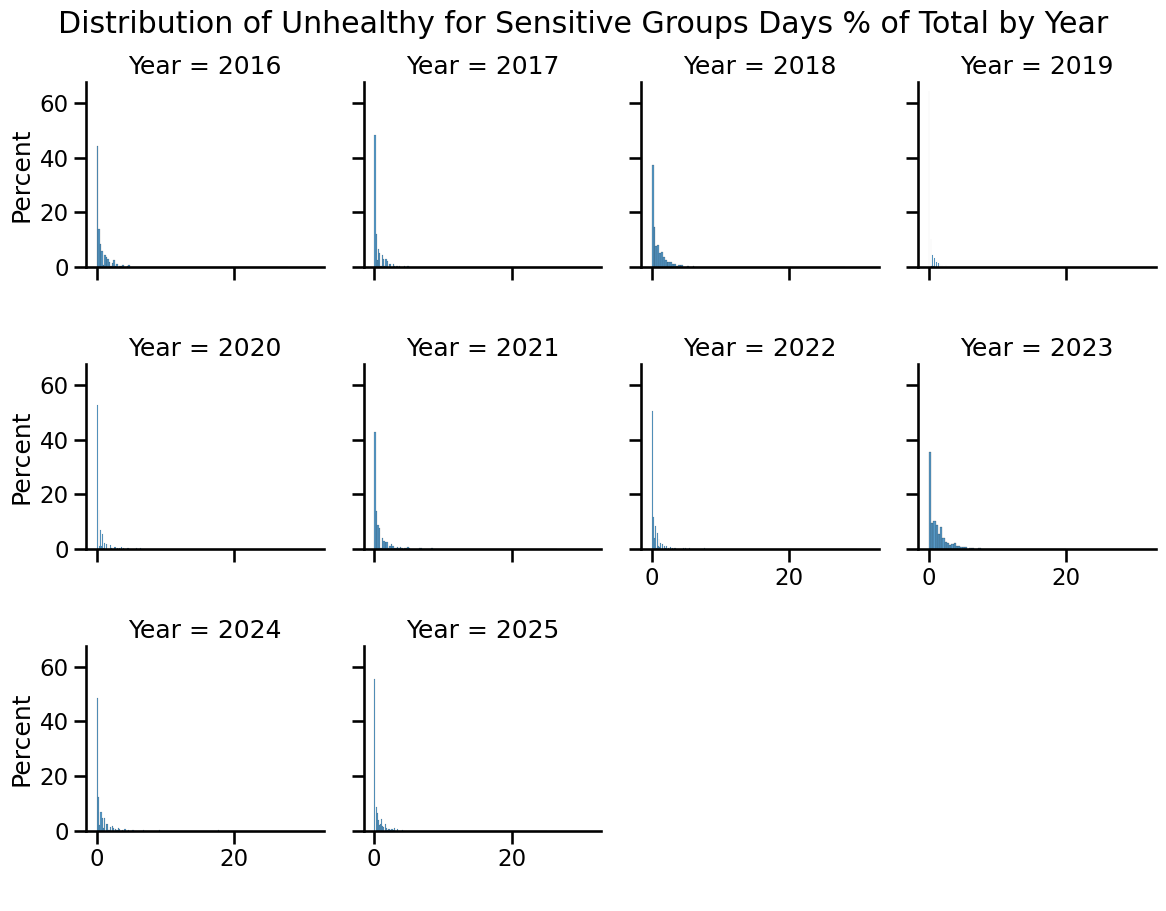

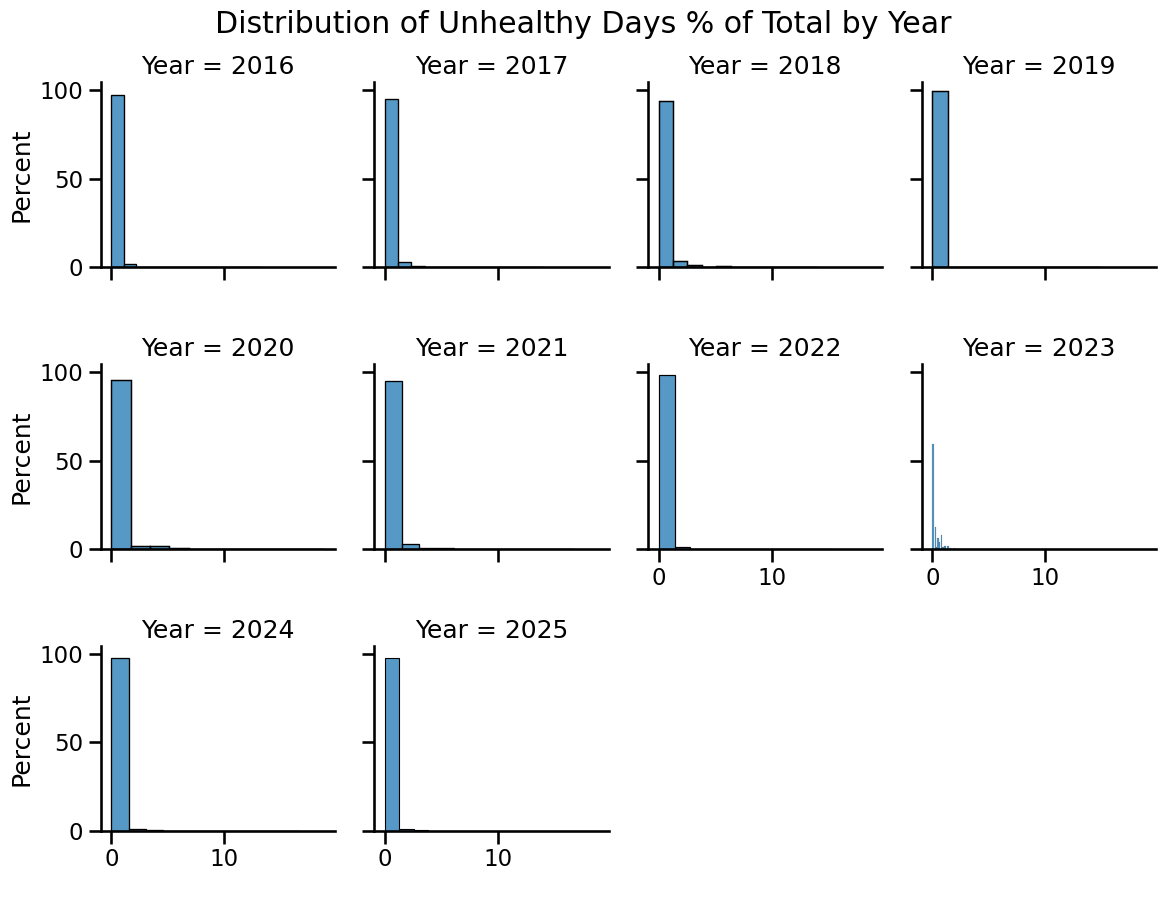

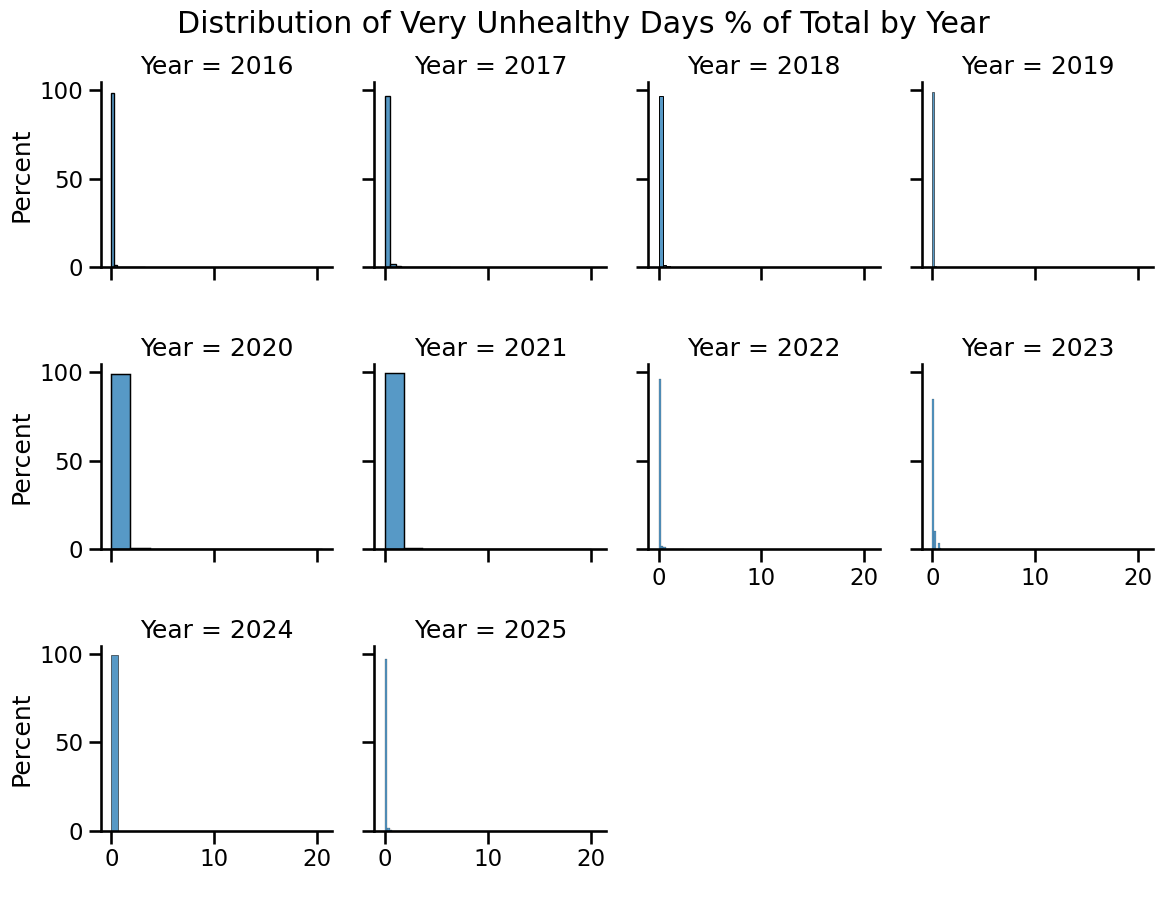

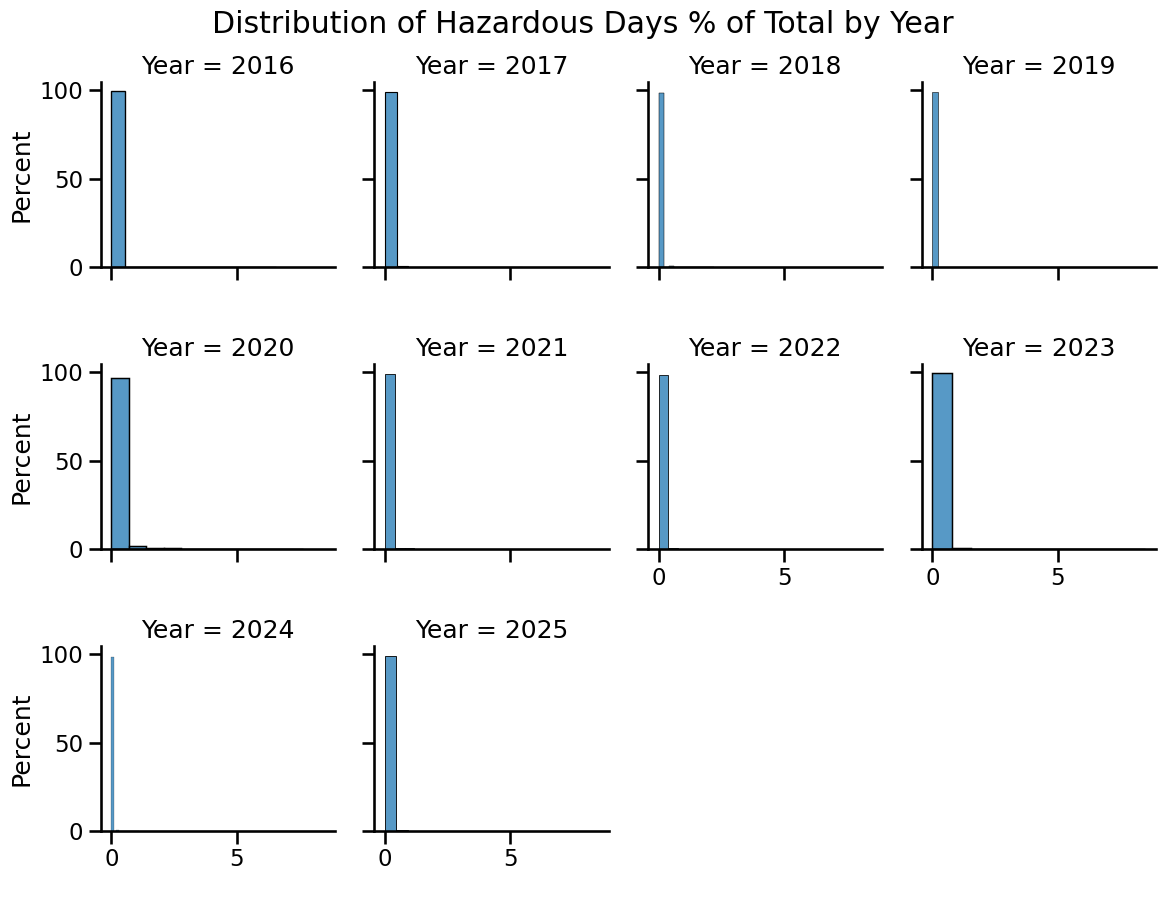

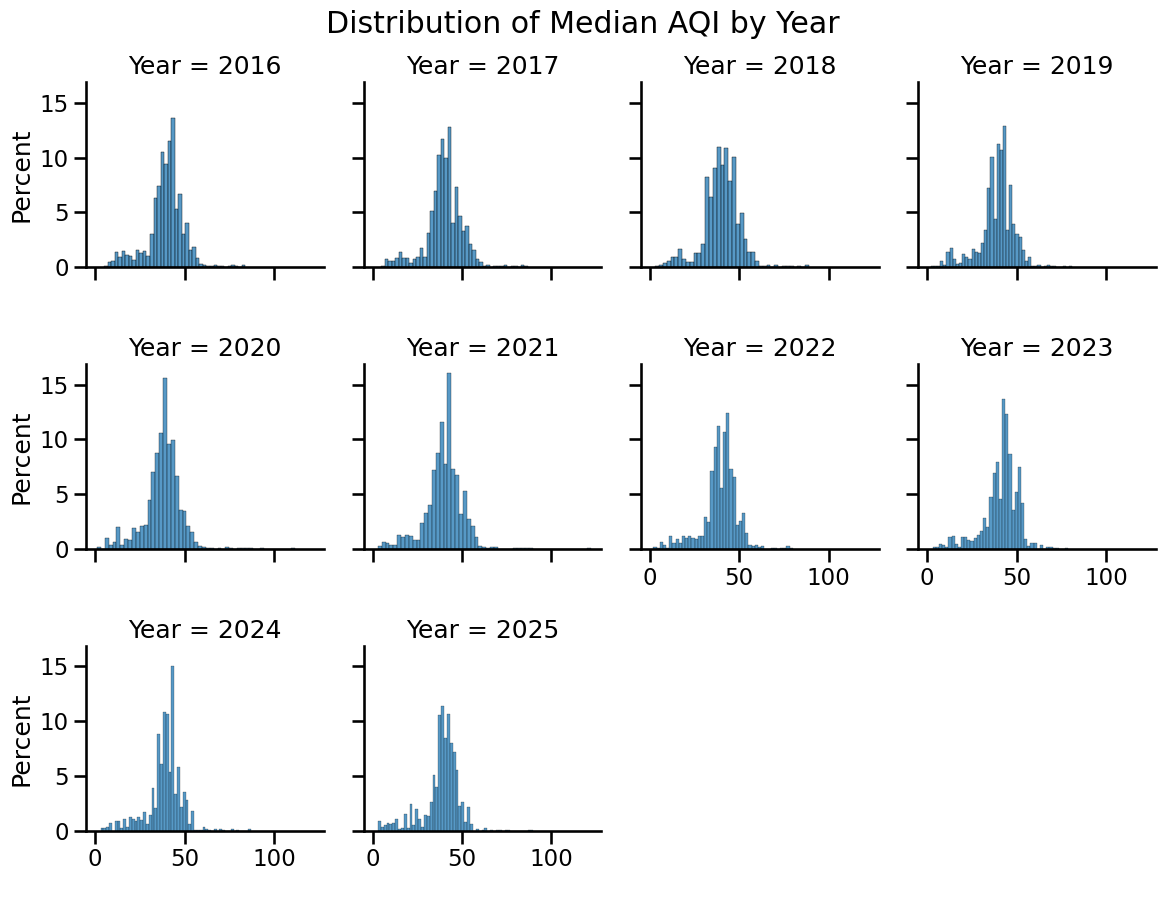

In [7]:



variables = ['Good Days % of Total', 'Unhealthy for Sensitive Groups Days % of Total', 'Unhealthy Days % of Total', 'Very Unhealthy Days % of Total', 'Hazardous Days % of Total','Median AQI']

for var in variables:
    g = sns.FacetGrid(merged_df, col="Year",  col_wrap=4)
    g.map_dataframe(sns.histplot, x=var, stat='percent')
    fig = g.figure
    fig.suptitle(f"Distribution of {var} by Year", y=1.02)
    # remove the x axis label
    g.set_axis_labels(" ", "Percent")
    #g.refline(x=merged_df[var].median())
    fig_save_path = figure_folder / f"{var.replace(' ', '_')}.png"
    fig.savefig(fig_save_path, bbox_inches='tight')

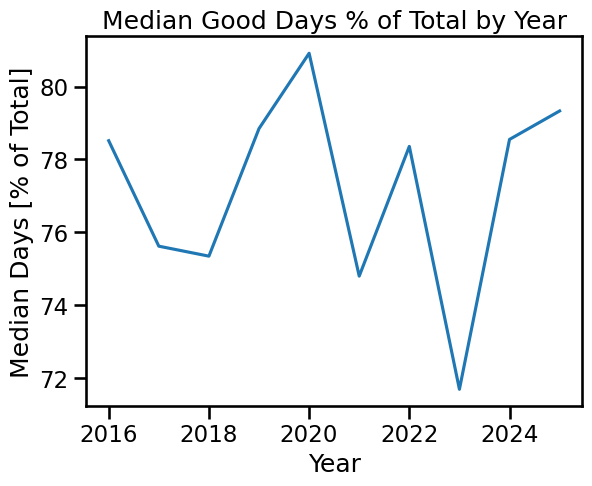

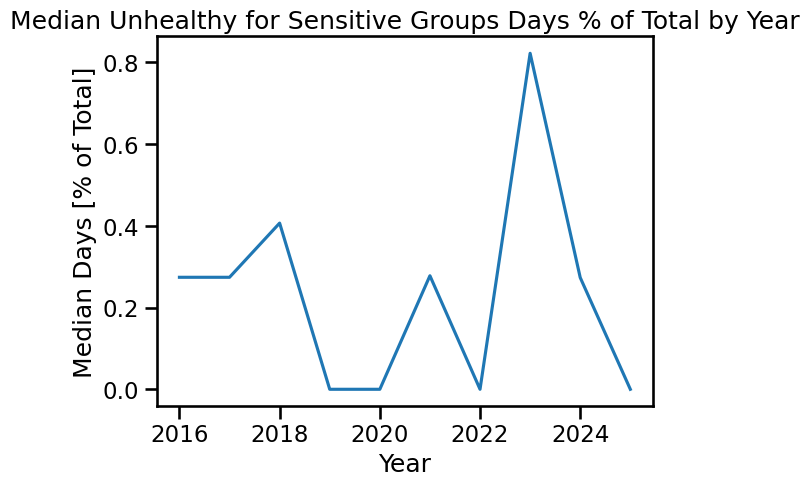

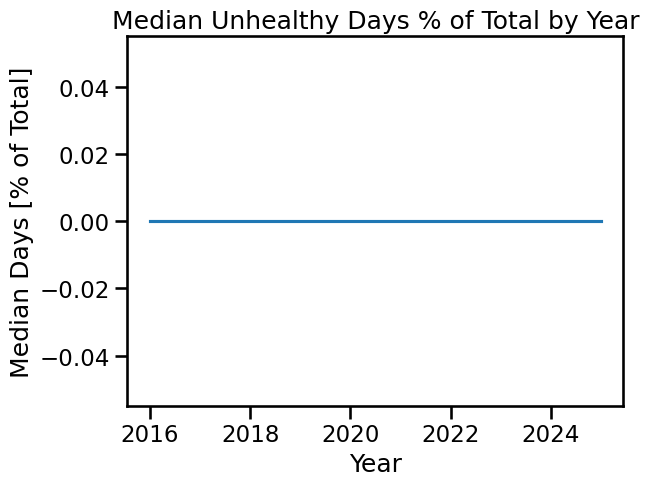

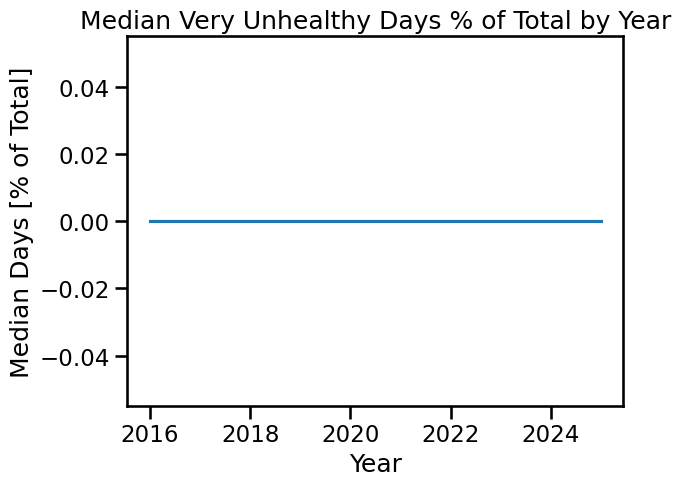

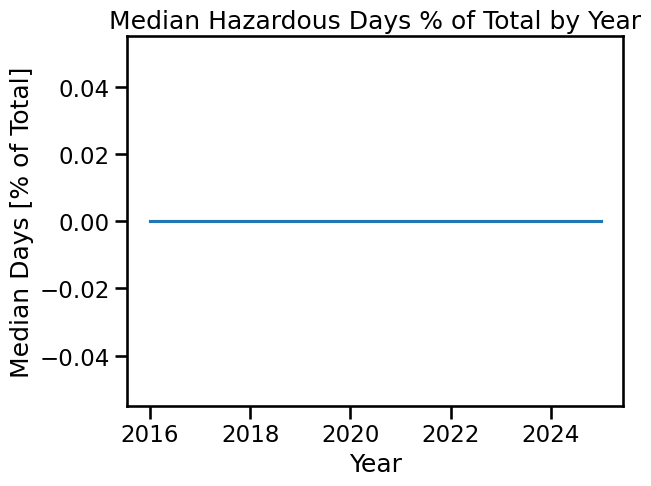

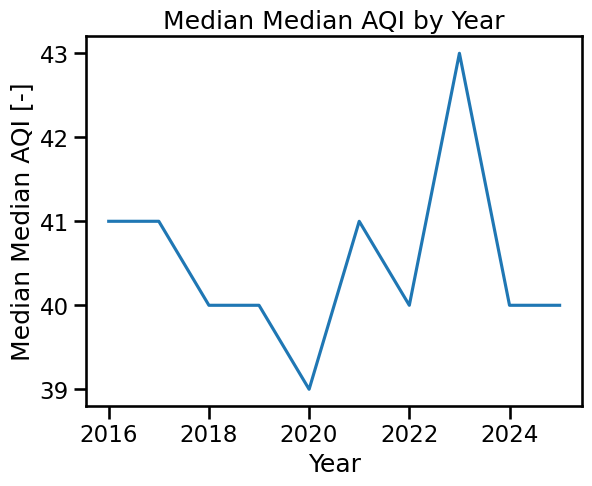

In [8]:
# group by year and calculate the median of each variable
median_by_year = merged_df.groupby('Year')[variables].median()

for var in variables:
    # plot the median of each variable by year using seaborn
    sns.lineplot(data=median_by_year, x='Year', y=var)
    plt.title(f"Median {var} by Year")
    plt.xlabel("Year")
    if "Days" in var:
        plt.ylabel(f"Median Days [% of Total]")
    else:   
        plt.ylabel(f"Median Median AQI [-]")

    fig_save_path = figure_folder / f"{var.replace(' ', '_')}_by_year.png"
    plt.savefig(fig_save_path, bbox_inches='tight')
    plt.show()
    plt.close()

## Visualize Average Across States

In [9]:
variables = ['Good Days % of Total', 'Median AQI']
grouped_data = merged_df.groupby(['Year', 'State'])[variables].median().add_prefix('median_')
grouped_data.reset_index(inplace = True)
print(grouped_data.head(10))

grouped_data_2 = grouped_data.groupby('Year').agg(
    min_median_good_days = ('median_Good Days % of Total', 'min'),
    max_median_good_days = ('median_Good Days % of Total', 'max'),
    min_median_aqi = ('median_Median AQI', 'min'),
    max_median_aqi = ('median_Median AQI', 'max')
)

grouped_data_2.reset_index(inplace = True)
print(grouped_data_2.head(10))

# iterate over grouped_data_2 and find the best / worst state for each year
for index, row in grouped_data_2.iterrows():
    year = row['Year']
    min_good_days = row['min_median_good_days']
    max_good_days = row['max_median_good_days']
    min_aqi = row['min_median_aqi']
    max_aqi = row['max_median_aqi']

    best_good_days_state = ''.join(np.unique(grouped_data[(grouped_data['Year'] == year) & (grouped_data['median_Good Days % of Total'] == max_good_days)]['State']).tolist())
    worst_good_days_state = ''.join(np.unique(grouped_data[(grouped_data['Year'] == year) & (grouped_data['median_Good Days % of Total'] == min_good_days)]['State']).tolist())
    best_aqi_state = ''.join(np.unique(grouped_data[(grouped_data['Year'] == year) & (grouped_data['median_Median AQI'] == min_aqi)]['State']).tolist())
    worst_aqi_state = ''.join(np.unique(grouped_data[(grouped_data['Year'] == year) & (grouped_data['median_Median AQI'] == max_aqi)]['State']).tolist())

    print(f"Year: {year}")
    print(f"Best Good Days States: {best_good_days_state} with {min_good_days:.2f}%")
    print(f"Worst Good Days States: {worst_good_days_state} with {max_good_days:.2f}%")
    print(f"Best AQI States: {best_aqi_state} with {min_aqi:.2f}")
    print(f"Worst AQI States: {worst_aqi_state} with {max_aqi:.2f}")
    print("-" * 40)

    grouped_data_2.at[index,'best_good_days_state'] = best_good_days_state
    grouped_data_2.at[index,'worst_good_days_state'] = worst_good_days_state
    grouped_data_2.at[index,'best_aqi_state'] = best_aqi_state
    grouped_data_2.at[index,'worst_aqi_state'] = worst_aqi_state


print(grouped_data_2.head(10))
    


   Year                 State  median_Good Days % of Total  median_Median AQI
0  2016               Alabama                    74.514601               41.5
1  2016                Alaska                    77.049180               33.0
2  2016               Arizona                    75.956284               44.0
3  2016              Arkansas                    62.608696               41.0
4  2016            California                    55.504118               47.5
5  2016              Colorado                    77.642467               44.0
6  2016           Connecticut                    75.415339               42.5
7  2016              Delaware                    70.765027               43.0
8  2016  District Of Columbia                    38.251366               53.0
9  2016               Florida                    76.229508               43.0
   Year  min_median_good_days  max_median_good_days  min_median_aqi  \
0  2016             38.251366             95.896025            24.0   


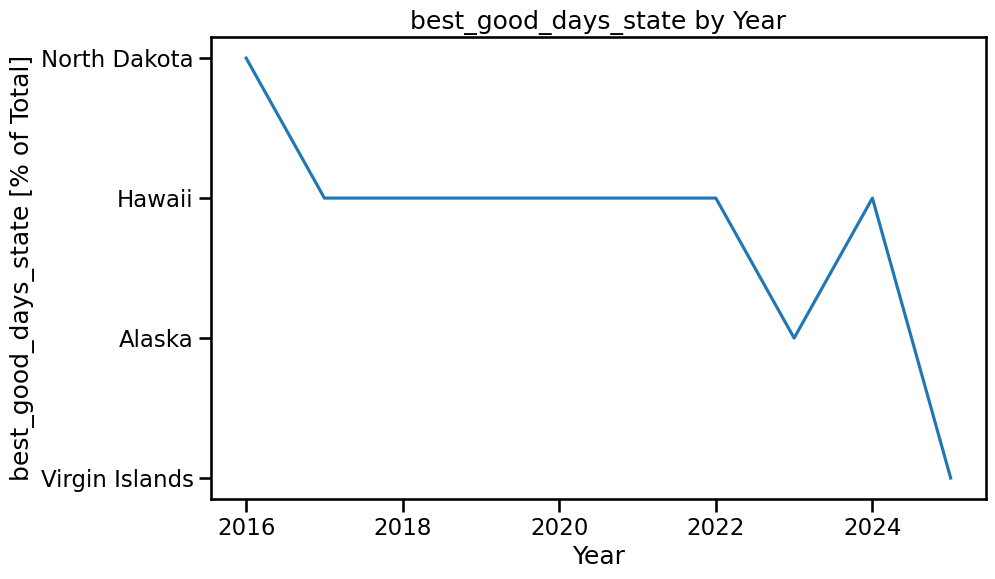

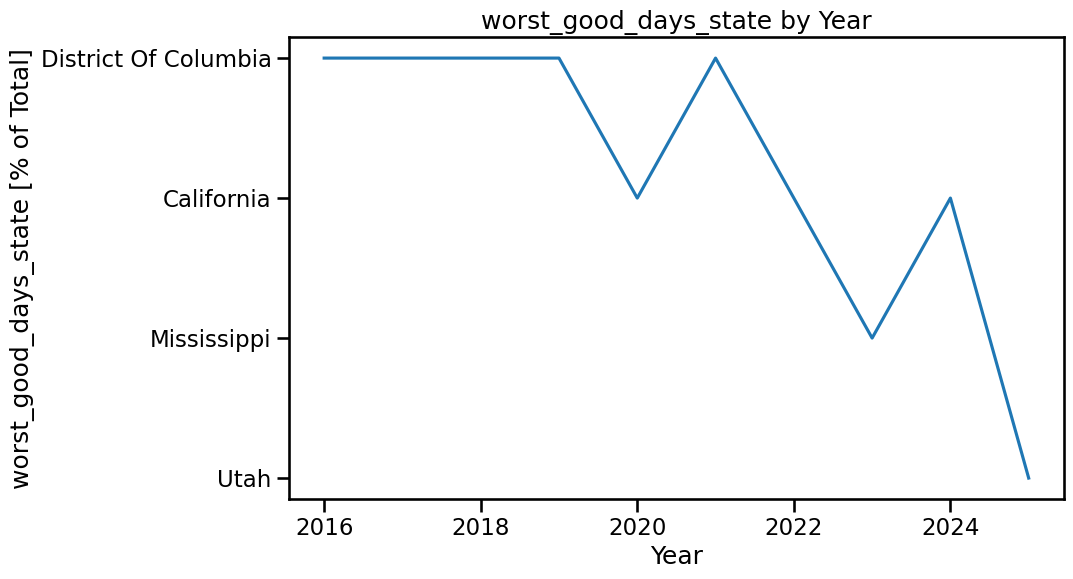

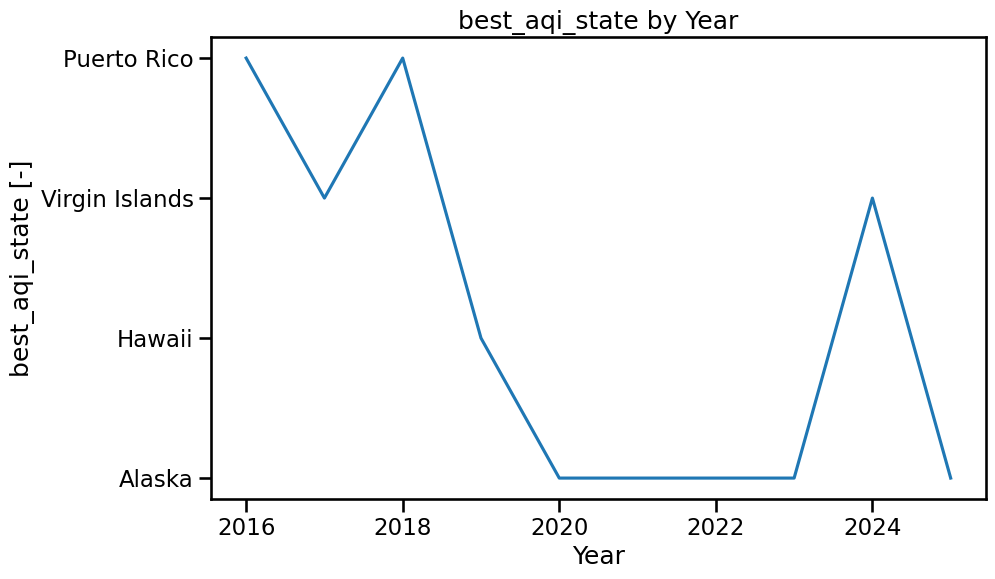

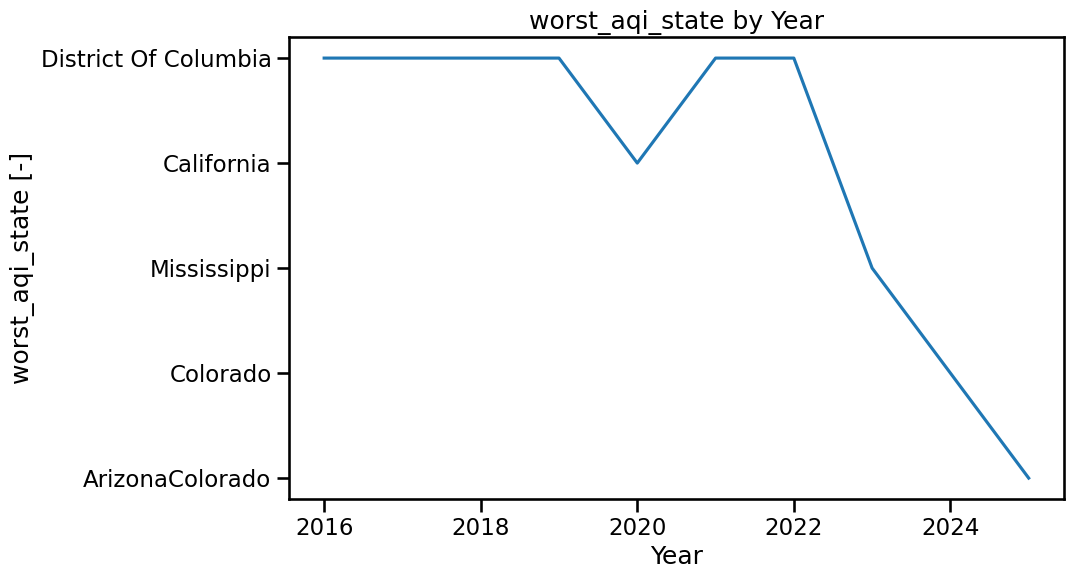

In [10]:
for v in ['best_good_days_state','worst_good_days_state','best_aqi_state','worst_aqi_state']:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=grouped_data_2, x='Year', y=v)
    plt.title(f"{v} by Year")
    plt.xlabel("Year")
    if "good_days" in v:
        plt.ylabel(f"{v} [% of Total]")
    else:   
        plt.ylabel(f"{v} [-]")
    fig_save_path = figure_folder / f"{v}_by_year.png"
    plt.savefig(fig_save_path, bbox_inches='tight')
    plt.show()
    plt.close()

## Find Worst 10 counties in terms of air quality